In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import re
import string

In [ ]:
dataframe=pd.read_csv("/content/drive/MyDrive/News.csv")

In [ ]:
dataframe.head()

,Unnamed: 0,title,text,subject,date,class
0,0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
dataframe.shape

(44919, 6)

In [ ]:

for i in range(44918,44908,-1):
    dataframe.drop([i], axis = 0, inplace = True)



In [ ]:
dataframe.shape

(44909, 6)

In [ ]:
dataframe = dataframe.drop(["title", "subject","date"], axis = 1)

In [ ]:
dataframe.isnull().sum()

Unnamed: 0    0
text          0
class         0
dtype: int64

In [ ]:
dataframedataframe = dataframe.sample(frac = 1)
dataframe.head()

,Unnamed: 0,text,class
0,0,Donald Trump just couldn t wish all Americans ...,0
1,1,House Intelligence Committee Chairman Devin Nu...,0
2,2,"On Friday, it was revealed that former Milwauk...",0
3,3,"On Christmas day, Donald Trump announced that ...",0
4,4,Pope Francis used his annual Christmas Day mes...,0


In [ ]:
dataframe.reset_index(inplace = True)
dataframe.drop(["index"], axis = 1, inplace = True)
dataframe.head()

,Unnamed: 0,text,class
0,0,Donald Trump just couldn t wish all Americans ...,0
1,1,House Intelligence Committee Chairman Devin Nu...,0
2,2,"On Friday, it was revealed that former Milwauk...",0
3,3,"On Christmas day, Donald Trump announced that ...",0
4,4,Pope Francis used his annual Christmas Day mes...,0


<Axes: xlabel='class', ylabel='count'>

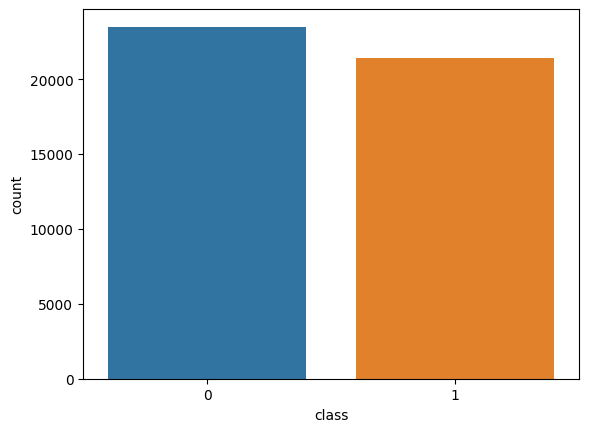

In [ ]:
sns.countplot(data=dataframe,	x='class',order=dataframe['class'].value_counts().index)



In [ ]:
from tqdm import tqdm
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def preprocess_text(text_data):
	preprocessed_text = []

	for sentence in tqdm(text_data):
		sentence = re.sub(r'[^\w\s]', '', sentence)
		preprocessed_text.append(' '.join(token.lower()
								for token in str(sentence).split()
								if token not in stopwords.words('english')))

	return preprocessed_text


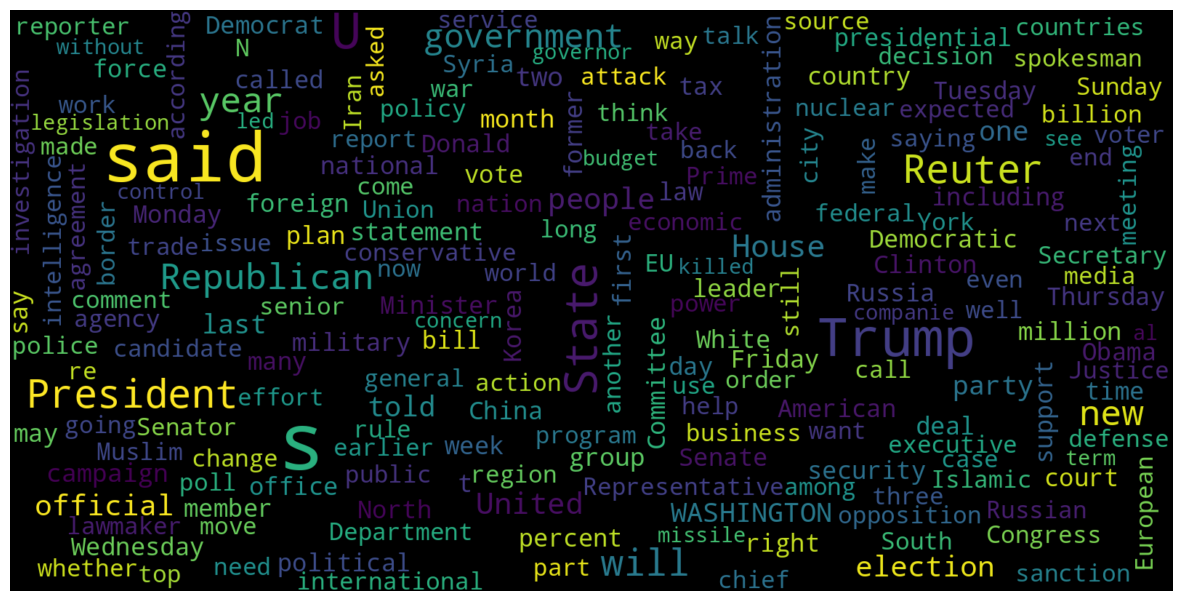

In [ ]:
# Real
consolidated = ' '.join(
	word for word in dataframe['text'][dataframe['class'] == 1].astype(str))
wordCloud = WordCloud(width=1600,
					height=800,
					random_state=21,
					max_font_size=110,
					collocations=False)
plt.figure(figsize=(15, 10))
plt.imshow(wordCloud.generate(consolidated), interpolation='bilinear')
plt.axis('off')
plt.show()

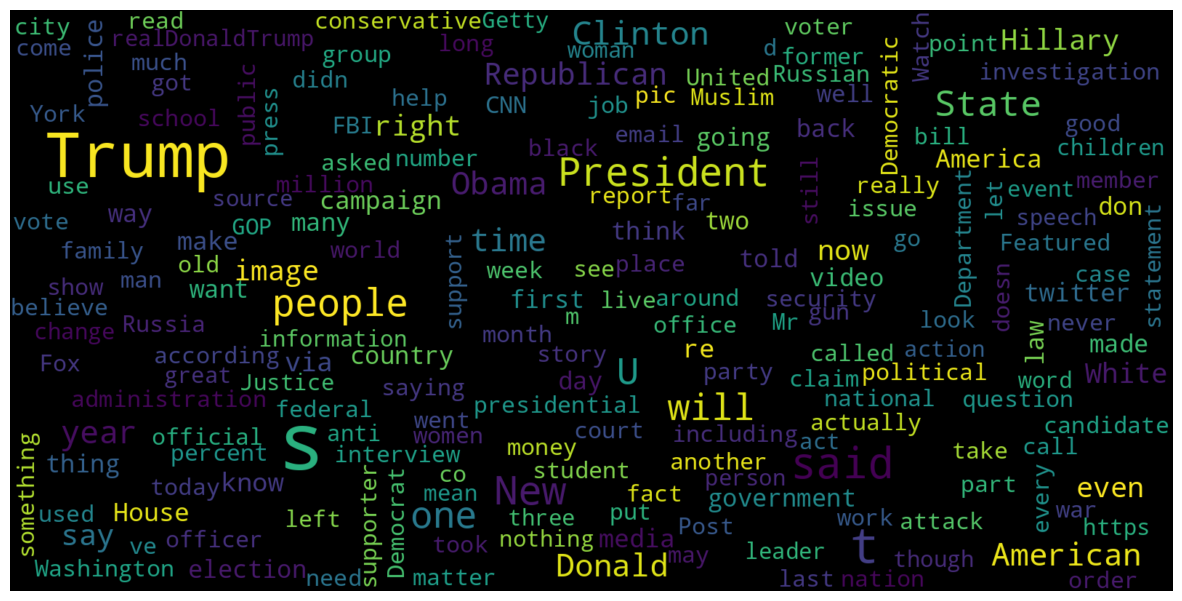

In [ ]:
# Fake
consolidated = ' '.join(
	word for word in dataframe['text'][dataframe['class'] == 0].astype(str))
wordCloud = WordCloud(width=1600,
					height=800,
					random_state=21,
					max_font_size=110,
					collocations=False)
plt.figure(figsize=(15, 10))
plt.imshow(wordCloud.generate(consolidated), interpolation='bilinear')
plt.axis('off')
plt.show()

<Axes: title={'center': 'Bar Chart of Top Words Frequency'}, xlabel='Top Words', ylabel='Count'>

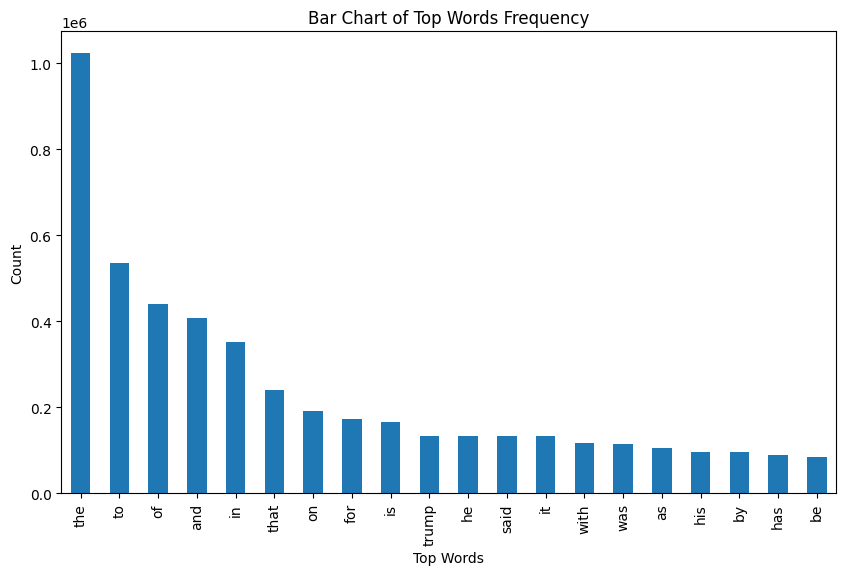

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


def get_top_n_words(corpus, n=None):
	vec = CountVectorizer().fit(corpus)
	bag_of_words = vec.transform(corpus)
	sum_words = bag_of_words.sum(axis=0)
	words_freq = [(word, sum_words[0, idx])
				for word, idx in vec.vocabulary_.items()]
	words_freq = sorted(words_freq, key=lambda x: x[1],
						reverse=True)
	return words_freq[:n]


common_words = get_top_n_words(dataframe['text'], 20)
df1 = pd.DataFrame(common_words, columns=['Review', 'count'])

df1.groupby('Review').sum()['count'].sort_values(ascending=False).plot(
	kind='bar',
	figsize=(10, 6),
	xlabel="Top Words",
	ylabel="Count",
	title="Bar Chart of Top Words Frequency"
)


In [ ]:
def wordopt(t):
    tt = t.lower()
    t = re.sub('\[.*?\]', '', t)
    t = re.sub("\\W"," ",t)
    t = re.sub('https?://\S+|www\.\S+', '', t)
    t = re.sub('<.*?>+', '', t)
    t = re.sub('[%s]' % re.escape(string.punctuation), '', t)
    t = re.sub('\n', '', t)
    t = re.sub('\w*\d\w*', '', t)
    return t


dataframe["text"] = dataframe["text"].apply(wordopt)

#Now we will define the dependent variable and independent variables
x = dataframe["text"]
y = dataframe["class"]

# Splitting the Dataset into a Training and Testing Set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression


LR = LogisticRegression()
LR.fit(xv_train,y_train)

pred_lr=LR.predict(xv_test)
LR.score(xv_test, y_test)



0.9857499109369433

In [ ]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5882
           1       0.98      0.99      0.99      5346

    accuracy                           0.99     11228
   macro avg       0.99      0.99      0.99     11228
weighted avg       0.99      0.99      0.99     11228



In [ ]:
from sklearn.tree import DecisionTreeClassifier


DT = DecisionTreeClassifier()
DT.fit(xv_train, y_train)

pred_dt = DT.predict(xv_test)
DT.score(xv_test, y_test)

print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      5882
           1       1.00      0.99      1.00      5346

    accuracy                           1.00     11228
   macro avg       1.00      1.00      1.00     11228
weighted avg       1.00      1.00      1.00     11228



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

GBC = GradientBoostingClassifier(random_state=0)
GBC.fit(xv_train, y_train)
pred_gbc = GBC.predict(xv_test)
GBC.score(xv_test, y_test)

print(classification_report(y_test, pred_gbc))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5882
           1       0.99      1.00      1.00      5346

    accuracy                           1.00     11228
   macro avg       1.00      1.00      1.00     11228
weighted avg       1.00      1.00      1.00     11228



In [ ]:
from sklearn.ensemble import RandomForestClassifier

RFC = RandomForestClassifier(random_state=0)
RFC.fit(xv_train, y_train)
pred_rfc = RFC.predict(xv_test)
RFC.score(xv_test, y_test)

print(classification_report(y_test, pred_rfc))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5882
           1       0.99      0.99      0.99      5346

    accuracy                           0.99     11228
   macro avg       0.99      0.99      0.99     11228
weighted avg       0.99      0.99      0.99     11228



In [ ]:
def output_lable(n):
    if n == 0:
        return "Fake News"
    elif n == 1:
        return "Not A Fake News"

def manual_testing(news):
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"] = new_def_test["text"].apply(wordopt)
    new_x_test = new_def_test["text"]
    new_xv_test = vectorization.transform(new_x_test)
    pred_LR = LR.predict(new_xv_test)
    pred_DT = DT.predict(new_xv_test)
    pred_GBC = GBC.predict(new_xv_test)
    pred_RFC = RFC.predict(new_xv_test)
    return print("\n\nLR Prediction: {} \nDT Prediction: {} \nGBC Prediction: {} \nRFC Prediction: {}".format(output_lable(pred_LR[0]),output_lable(pred_DT[0]), output_lable(pred_GBC[0]), output_lable(pred_RFC[0])))







In [ ]:
news = str(input())
manual_testing(news)

JAKARTA (Reuters) - Indonesian anti-terrorism police have detained 18 people with links to militant groups in a bid to cut the risk of attacks during Christmas and the New Year in the world s biggest Muslim-majority country, police said on Monday. Near-simultaneous attacks on churches in the capital, Jakarta, and elsewhere on Christmas Eve in 2000, killed nearly 20 people. Ever since, authorities have stepped up security at churches and tourist spots for the holiday. Police Chief Tito Karnavian said while there was no evidence of a specific plot, the detentions were made in a bid to head off trouble.  We re doing a pre-emptive strike,  Karnavian told reporters.       The majority of them have links to previous incidents (and people) who we had arrested earlier,  he said. Police said that 12 people had been detained in South Sumatra, four in West Kalimantan, one in Malang in East Java and one in Surabaya in the same province. Under Indonesia s anti-terrorism laws, investigators can hold